# Korea Income & Welfare

English-first companion notebook for the portfolio version of the project.

## Purpose

This notebook is the clean public-facing companion to the repository. It reads the exported outputs produced by `scripts/income_welfare_analysis.py`, shows the main benchmarks, and keeps the portfolio layer understandable for non-Spanish readers.

The original exploratory notebook in Spanish is preserved in `archive/income_welfare_modeling_legacy_es.ipynb`.

In [1]:
from pathlib import Path
from IPython.display import Image, display

BASE_DIR = Path.cwd()
required_paths = [
    BASE_DIR / r'outputs/tables/education_income_summary.csv',
    BASE_DIR / r'outputs/tables/region_income_summary.csv',
    BASE_DIR / r'outputs/tables/model_comparison.csv',
    BASE_DIR / r'outputs/tables/feature_importance.csv',
    BASE_DIR / r'outputs/figures/income_by_education.png',
    BASE_DIR / r'outputs/figures/median_income_by_region.png',
    BASE_DIR / r'outputs/figures/top_feature_importance.png',
]

missing = [str(path) for path in required_paths if not path.exists()]
if missing:
    missing_list = '\n- '.join(missing)
    raise FileNotFoundError(
        f"Run `python scripts/income_welfare_analysis.py` first. Missing files:\n- {missing_list}"
    )

print('All required outputs are available.')


All required outputs are available.


In [2]:
from pathlib import Path
import pandas as pd

BASE_DIR = Path.cwd()
education_summary = pd.read_csv(BASE_DIR / 'outputs/tables/education_income_summary.csv')
region_summary = pd.read_csv(BASE_DIR / 'outputs/tables/region_income_summary.csv')
model_comparison = pd.read_csv(BASE_DIR / 'outputs/tables/model_comparison.csv')
feature_importance = pd.read_csv(BASE_DIR / 'outputs/tables/feature_importance.csv')

best_model = model_comparison.iloc[0]
top_education = education_summary.sort_values('average_income_usd', ascending=False).iloc[0]
top_region = region_summary.iloc[0]

print(f"Top education tier: {top_education['education_label']} ({top_education['average_income_usd']:.2f} USD average income)")
print(f"Top region by median income: {top_region['region_label']} ({top_region['median_income_usd']:.2f} USD)")
print('\nModel comparison:')
print(model_comparison.to_string(index=False))
print('\nTop 10 feature importances:')
print(feature_importance.head(10).to_string(index=False))

Top education tier: Doctorate (8246.68 USD average income)
Top region by median income: Seoul (2883.64 USD)

Model comparison:
                           model     mae_usd    rmse_usd       r2
     Multivariable random forest  908.879585 1279.935787 0.627646
 Multivariable linear regression 1049.827596 1414.492028 0.545242
Education-only linear regression 1345.399114 1762.556983 0.293901

Top 10 feature importances:
                      feature  importance
                family_member    0.523167
              education_level    0.151411
                          age    0.122256
                         year    0.101621
marriage_label_Not applicable    0.043294
           region_label_Seoul    0.007561
        region_label_Gyeonggi    0.007465
region_label_South Gyeongsang    0.007465
 region_label_Jeolla and Jeju    0.005856
  religion_label_Has religion    0.005622


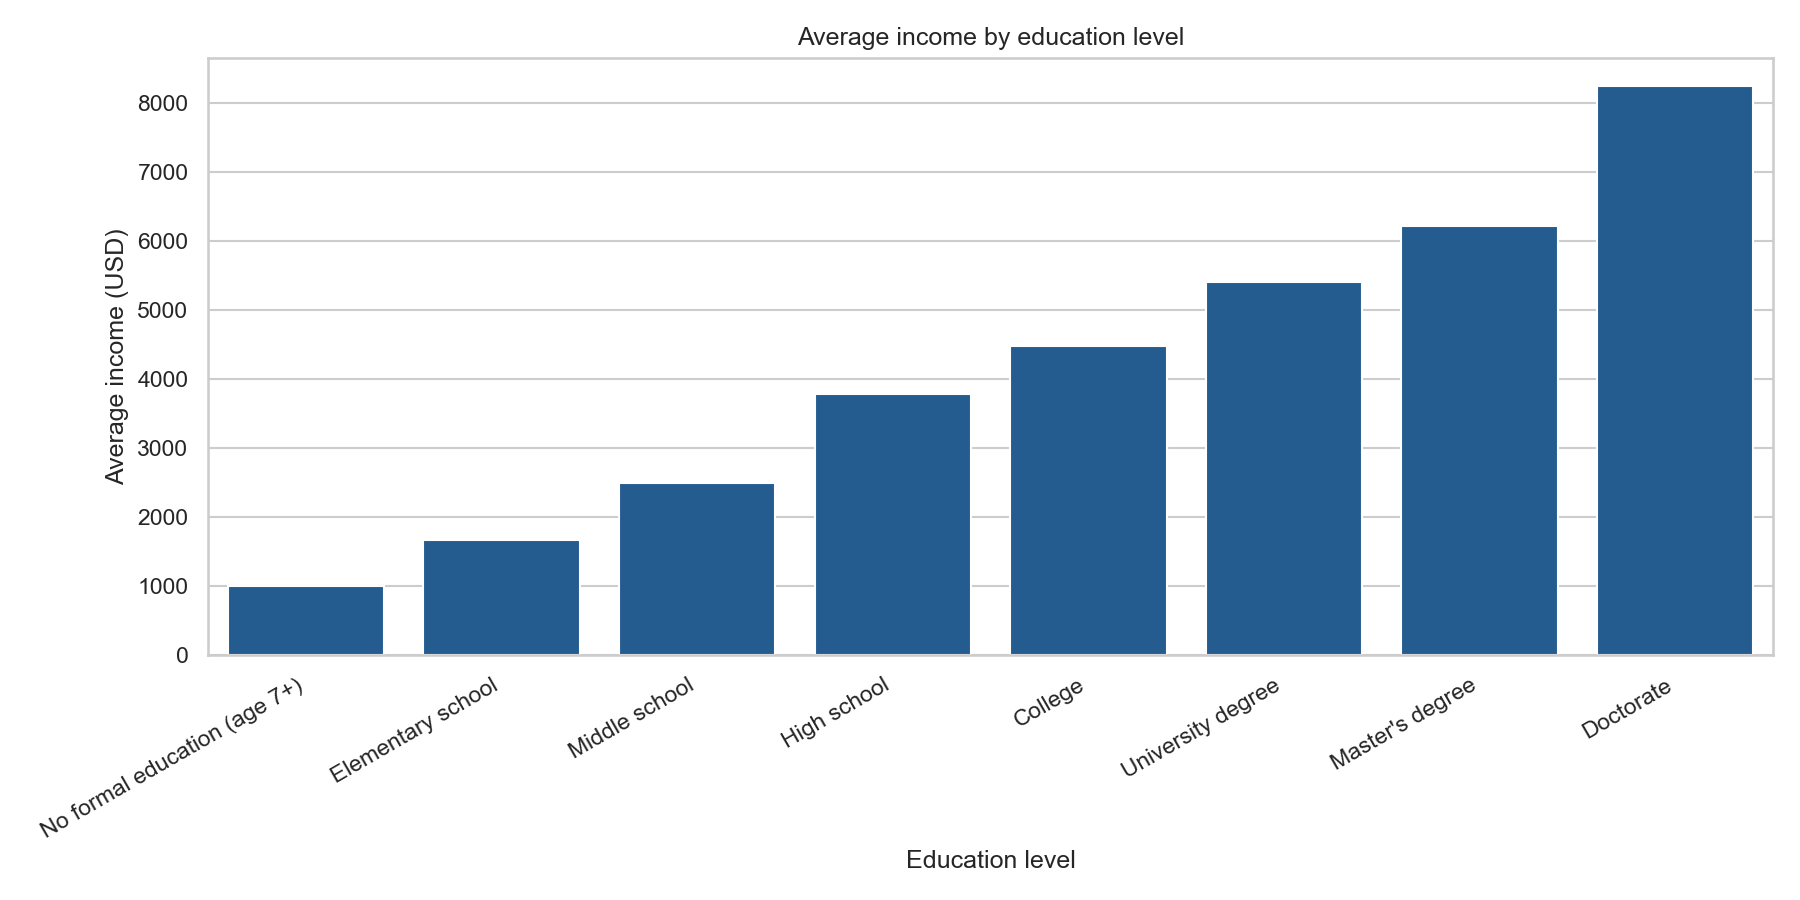

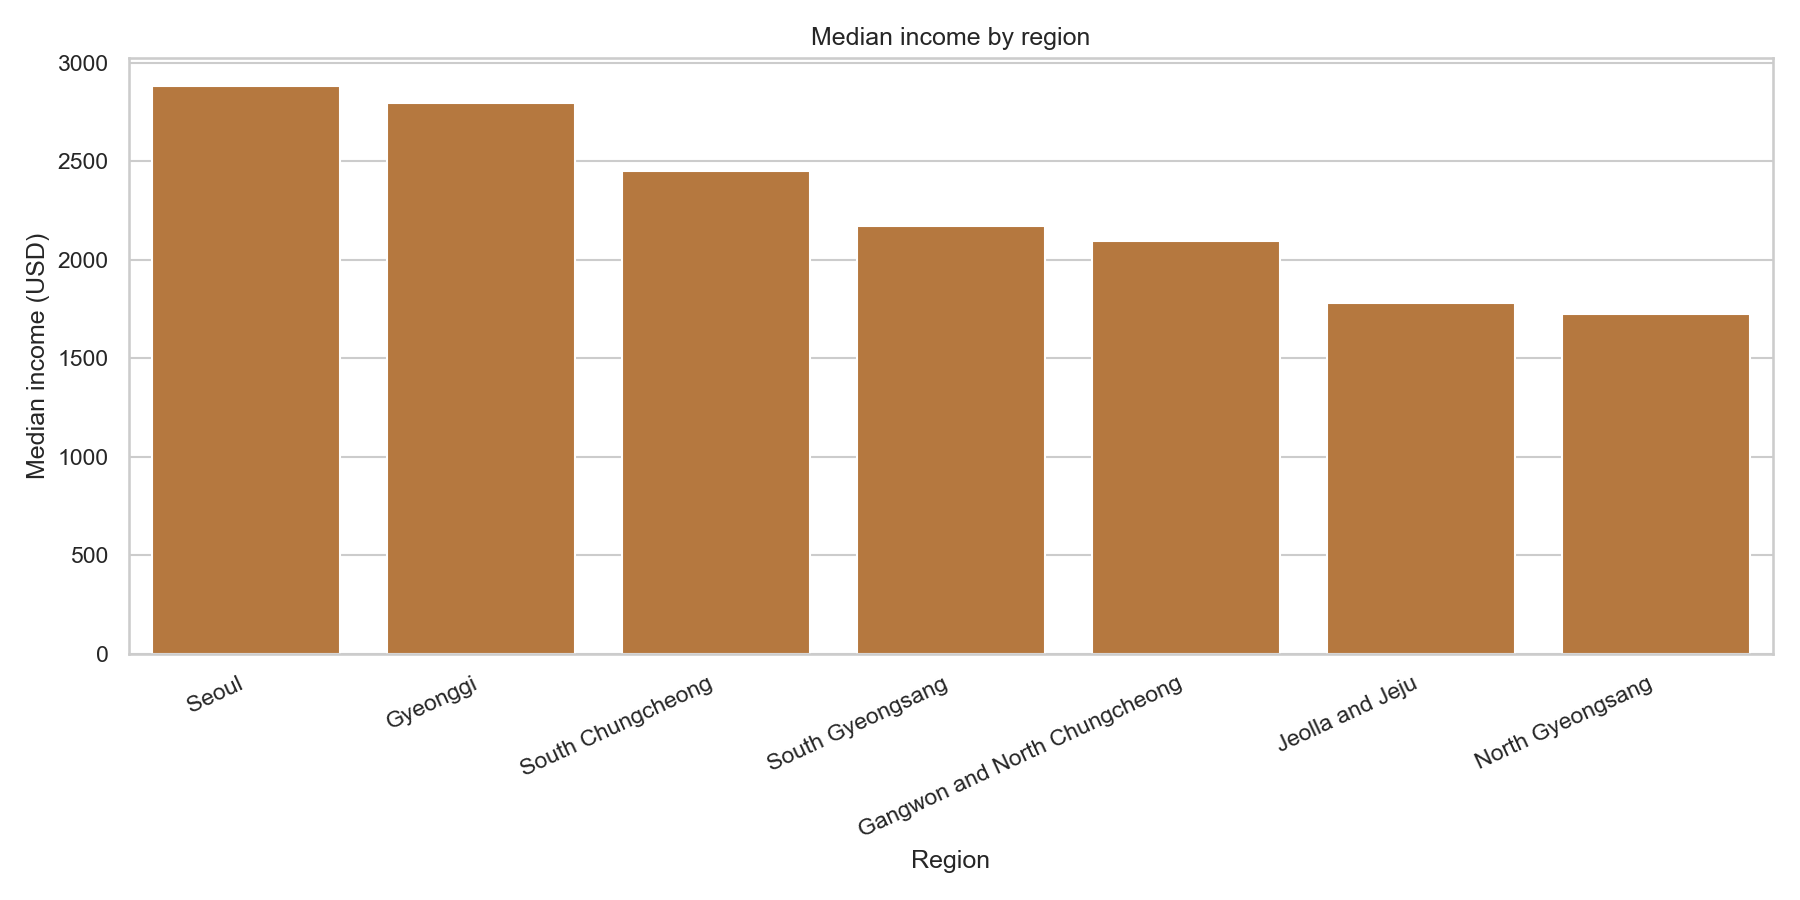

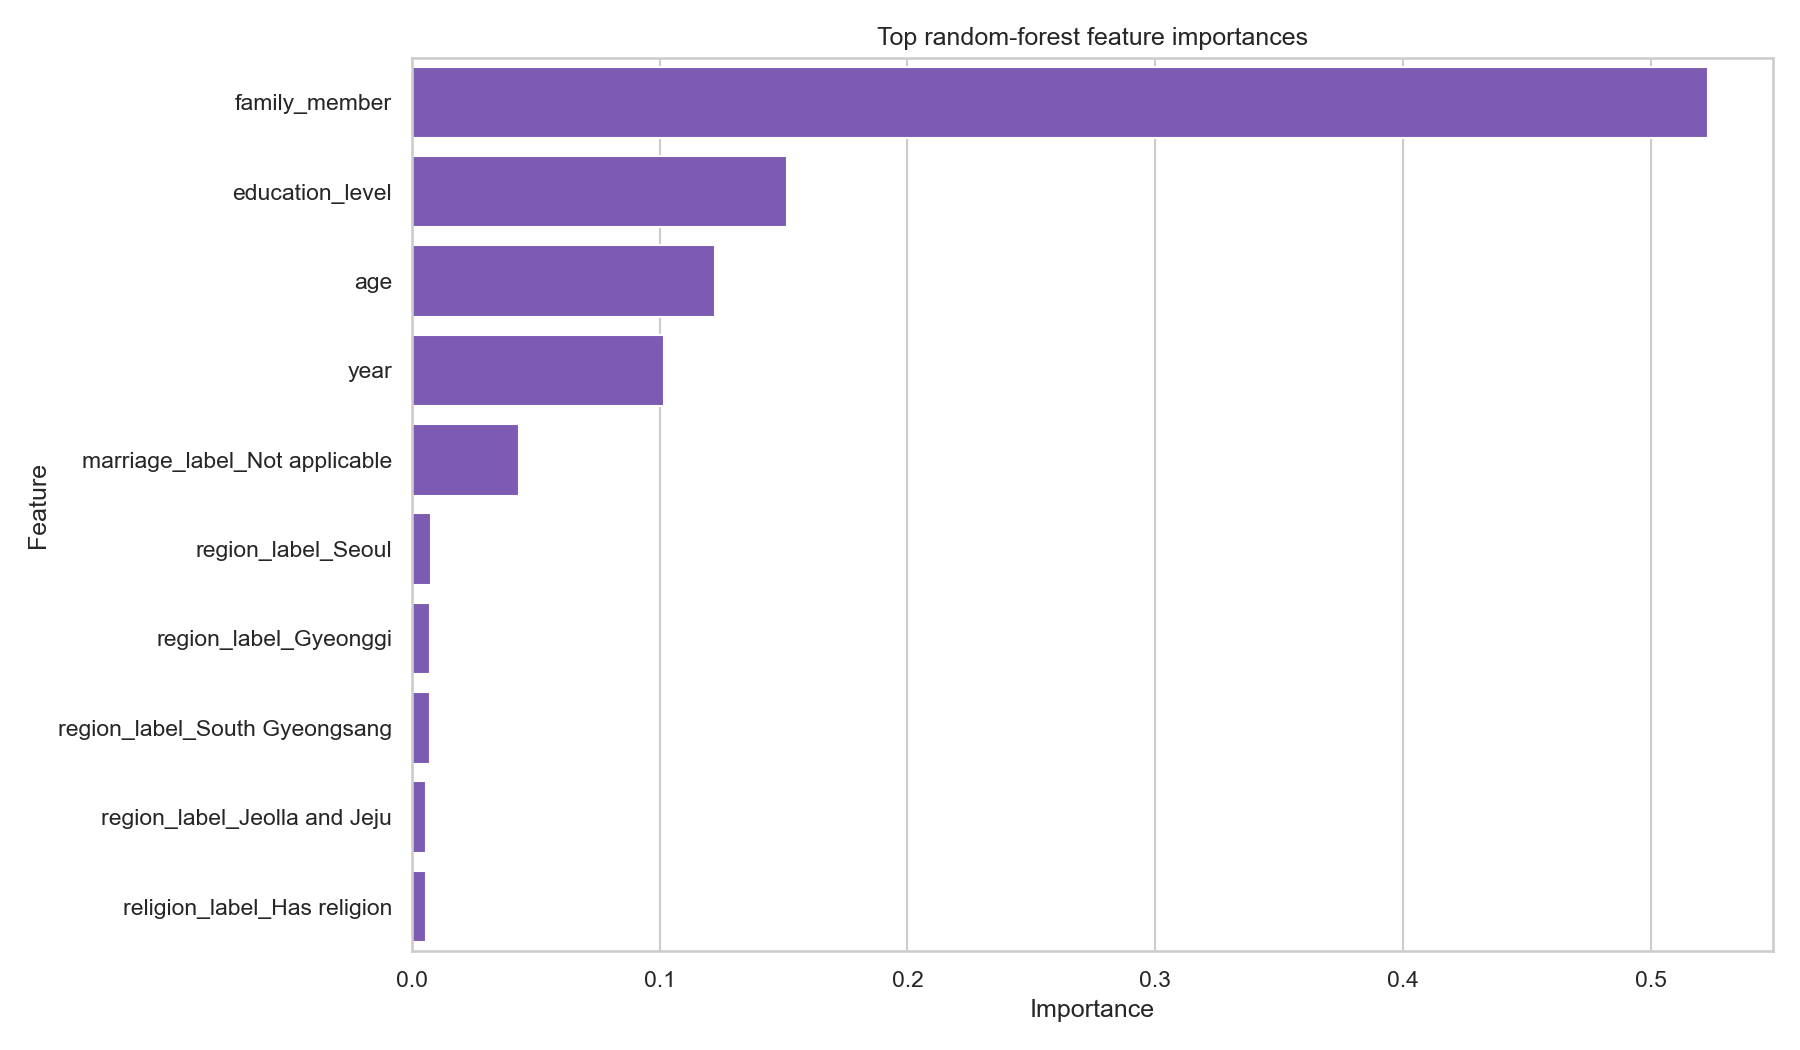

In [3]:
for figure_path in [
    BASE_DIR / r'outputs/figures/income_by_education.png',
    BASE_DIR / r'outputs/figures/median_income_by_region.png',
    BASE_DIR / r'outputs/figures/top_feature_importance.png',
]:
    display(Image(filename=str(figure_path)))
